# Transmon Leakage

In [ ]:
using Piccolo
using SparseArrays
using Random; Random.seed!(123)
using CairoMakie
using LinearAlgebra
using Optim

In [ ]:
import Pkg
#Pkg.rm("HarmonicSolvers")
#Pkg.gc()
Pkg.develop(path="/Users/jetta/Downloads/Quantum-main/Quantum-main/DiffEQ/HarmonicSolvers/")


In [ ]:
using HarmonicSolvers

In [ ]:
const T0 = 10.0    
const N  = 50       
const dt = T0 / N
const times = collect(range(0, T0, length = N))

const LEVELS = 3
const DELTA  = 0.2   
const U_BOUND = [0.2, 0.2]
const DDU_BOUND = 1.0

## 1. Baseline leakage visualization


In [ ]:
sys = TransmonSystem(drive_bounds = U_BOUND, levels = LEVELS, δ = DELTA)
op  = EmbeddedOperator(:X, sys)

initial_controls = 0.1 * randn(2, N)
pulse0 = ZeroOrderPulse(initial_controls, times)

qtraj = UnitaryTrajectory(sys, pulse0, op)


qcp = SmoothPulseProblem(qtraj, N; ddu_bound = DDU_BOUND, Q = 100.0, R = 1e-2)
solve!(qcp; max_iter = 50, eval_hessian=false)

qcp_leakage = SmoothPulseProblem(
    qtraj,
    N;
    ddu_bound = DDU_BOUND,
    Q = 100.0,
    R = 1e-2,
    piccolo_options = PiccoloOptions(
        leakage_constraint = true,
        leakage_constraint_value = 1e-2,
        leakage_cost = 1e-2,
    ),
)
solve!(qcp_leakage; max_iter = 50, eval_hessian = false)

In [ ]:
fig_naive = plot_unitary_populations(get_trajectory(qcp); fig_size = (900, 700))

In [ ]:
fig_leakage_suppressed = plot_unitary_populations(get_trajectory(qcp_leakage); fig_size = (900, 700))

In [ ]:
function final_leakage_population(qcp, sys)
    qtraj = get_trajectory(qcp)
    
    named_traj = get_named_trajectory(qcp) 


    fid = unitary_rollout_fidelity(qtraj, named_traj, sys)


    pulse_opt = extract_pulse(qtraj, named_traj)
    
    qtraj_opt = rollout(UnitaryTrajectory(sys, pulse_opt, EmbeddedOperator(:X, sys)))
    
    T_final = named_traj.t[end]
    U_final = qtraj_opt(T_final)
    
    leak = abs2(U_final[3, 1])

    return fid, leak
end


## 2. Traditional DRAG


In [ ]:

const DRAG_SIGMA = T0 / 6
const DRAG_AMP   = pi/ (DRAG_SIGMA*sqrt(2pi)) 

I_env(t)  = DRAG_AMP * exp(-(t - T0/2)^2 / (2 * DRAG_SIGMA^2))
dI_env(t) = -((t - T0/2) / DRAG_SIGMA^2) * I_env(t)  

Q_env(t)  = -dI_env(t) / DELTA

drag_control(t) = [I_env(t), Q_env(t)]

In [ ]:

plot_t_grid = collect(range(0, T0, length = N))

pulse_drag = try
    FunctionPulse(drag_control, T0, 2)
catch e
    @warn "FunctionPulse constructor failed, falling back to densely-sampled ZeroOrderPulse" exception=e
    dense_controls = reduce(hcat, drag_control.(plot_t_grid))
    ZeroOrderPulse(dense_controls, plot_t_grid)
end
qtraj_drag = UnitaryTrajectory(sys, pulse_drag, op)


# fddscretize the pulse manually into a discrete structure for plotting
dense_controls = reduce(hcat, drag_control.(plot_t_grid))
plot_pulse_discrete = ZeroOrderPulse(dense_controls, plot_t_grid)
plot_qtraj_discrete = UnitaryTrajectory(sys, plot_pulse_discrete, op)


named_traj_drag = NamedTrajectory(plot_qtraj_discrete, N)

fig_drag = plot_unitary_populations(named_traj_drag; fig_size = (900, 700))


In [ ]:
fid_drag = fidelity(qtraj_drag)
U_drag_final = qtraj_drag(T0)
leak_drag = abs2(U_drag_final[3, 1])

println("DRAG: fidelity = ", fid_drag, ", leakage pop = ", leak_drag)

## 3. GRAPE (Optim.jl + HarmonicSolvers)


In [ ]:

a = zeros(ComplexF64, LEVELS, LEVELS)
for k in 1:(LEVELS - 1)
    a[k, k+1] = sqrt(k)
end
a_dag = a'
n_op = a_dag * a

H_drift = (DELTA / 2) * (n_op * (n_op - I))   # anharmonicity delta/2 * n(n-1)
H_I = a + a_dag
H_Q = 1im * (a - a_dag)

ψ0_t = ComplexF64[1.0, 0.0, 0.0]
ψtarget_t = ComplexF64[0.0, 1.0, 0.0]

rk4_solver = HarmonicSolvers.RungeKutta4()
LEAK_WEIGHT = 5.0   

In [ ]:
using DifferentialEquations

function schrodinger_transmon_native!(dψ, ψ, p, t)
    Hd, HI, HQ, uI_vals, uQ_vals, dt_ = p

    idx = clamp(floor(Int, t / dt_) + 1, 1, length(uI_vals))

    H = Hd + uI_vals[idx] * HI + uQ_vals[idx] * HQ

    mul!(dψ, H, ψ, -1im, 0)
    return nothing
end

function run_transmon(uI_vals, uQ_vals)
    params = (H_drift, H_I, H_Q, uI_vals, uQ_vals, dt)
    prob = ODEProblem(schrodinger_transmon_native!, ψ0_t, (0.0, T0), params)
    
    sol = solve(prob, Tsit5(); tstops=collect(0:dt:T0), abstol=1e-8, reltol=1e-8)
    return sol
end


function grape_objective(uI_vals, uQ_vals)
    sol = run_transmon(uI_vals, uQ_vals)
    ψ_final = sol.u[end]
    fid = abs2(dot(ψtarget_t, ψ_final))
    leak = abs2(ψ_final[3])
    return (1.0 - fid) + LEAK_WEIGHT * leak
end

grape_objective (generic function with 1 method)

In [26]:
# --- Objective 1: raw per-timestep controls (your original `objective`) ---
function objective_raw(controls_flat)
    uI_vals = controls_flat[1:N]
    uQ_vals = controls_flat[N+1:2N]
    return grape_objective(uI_vals, uQ_vals)
end

init_raw = 0.1 * randn(2N)
result_raw = optimize(objective_raw, init_raw, NelderMead(),
                       Optim.Options(iterations = 2000))
best_raw = Optim.minimizer(result_raw)

println("Objective 1 (raw) final infidelity+leakage = ", Optim.minimum(result_raw))

Objective 1 (raw) final infidelity+leakage = 0.7416966669582524


In [27]:
# --- Objective 2: smooth cosine-basis controls (your original `objective_v2`) ---
function cosine_basis(n_modes::Int, N::Int)
    # Ensure times are explicitly bounded strictly from 0 to N-1
    τ = collect(0:(N-1)) ./ (N - 1) 
    return [cos.(pi * j .* (τ .- 0.5)) for j in 0:(n_modes - 1)]
end


function expand_control(coefficients, basis)
    return sum(c .* b for (c, b) in zip(coefficients, basis))
end

n_modes = 4
g_basis = cosine_basis(n_modes, N)

function objective_smooth(coeffs)
    cI = coeffs[1:n_modes]
    cQ = coeffs[n_modes+1:2n_modes]
    uI_vals = expand_control(cI, g_basis)
    uQ_vals = expand_control(cQ, g_basis)
    return grape_objective(uI_vals, uQ_vals)
end

init_smooth = 0.1 * randn(2n_modes)
result_smooth = optimize(objective_smooth, init_smooth, NelderMead(),
                          Optim.Options(iterations = 2000))
best_smooth_coeffs = Optim.minimizer(result_smooth)

println("Objective 2 (smooth basis) final infidelity+leakage = ", Optim.minimum(result_smooth))

Objective 2 (smooth basis) final infidelity+leakage = 3.1135804654229265e-9


### Visualizing GRAPE leakage populations



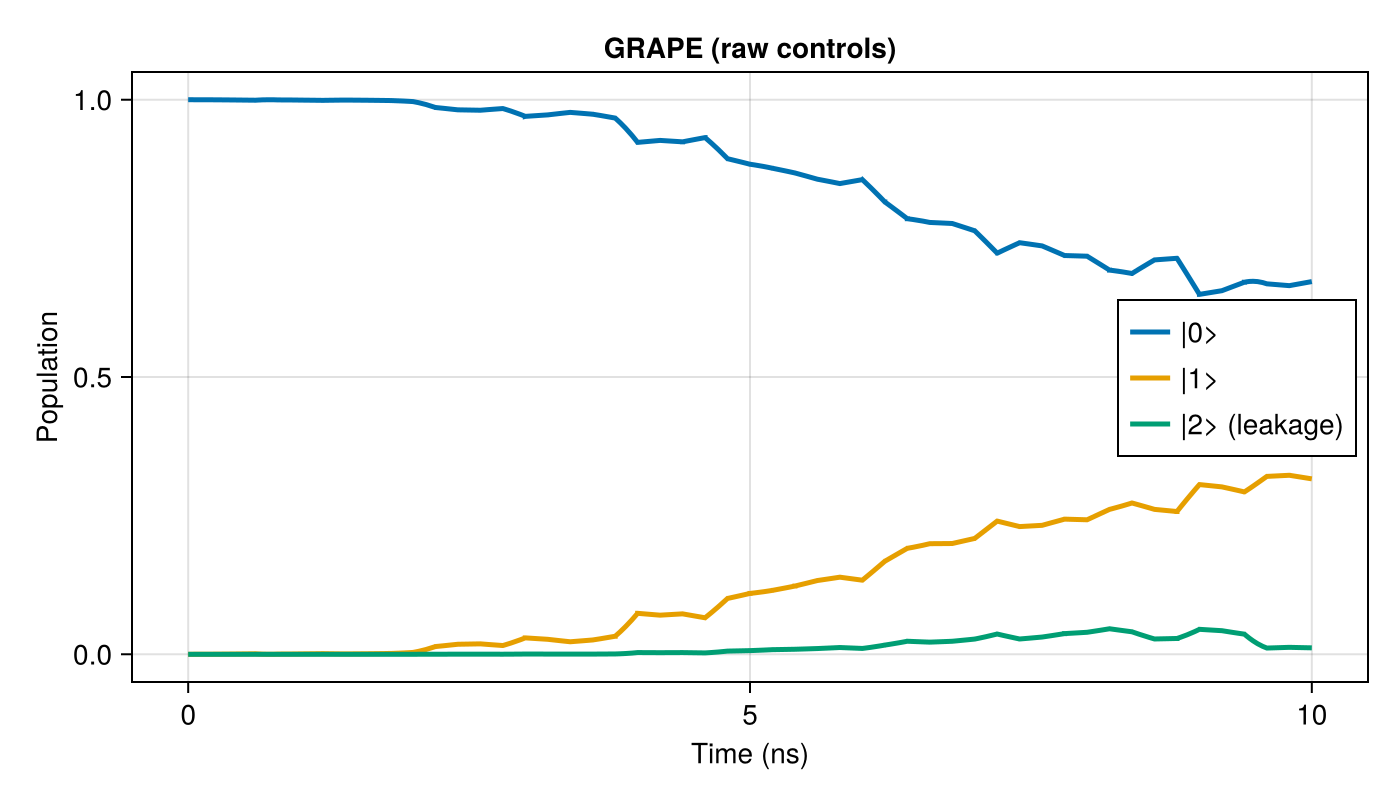

In [ ]:
function population_trajectory(uI_vals, uQ_vals)
    sol = run_transmon(uI_vals, uQ_vals)
    pops = reduce(hcat, [abs2.(psi) for psi in sol.u])   # LEVELS x length(times) matrix
    return sol.t, pops
end

function plot_populations(t, pops; title = "Populations")
    fig = Figure(size = (700, 400))
    ax = Axis(fig[1, 1], xlabel = "Time (ns)", ylabel = "Population", title = title)
    labels = ["|0>", "|1>", "|2> (leakage)"]
    for lvl in 1:LEVELS
        lines!(ax, t, pops[lvl, :], label = labels[lvl], linewidth = 2.5)
    end
    axislegend(ax, position = :rc)
    return fig
end

t_raw, pops_raw = population_trajectory(best_raw[1:N], best_raw[N+1:2N])
fig_grape_raw = plot_populations(t_raw, pops_raw; title = "GRAPE (raw controls)")

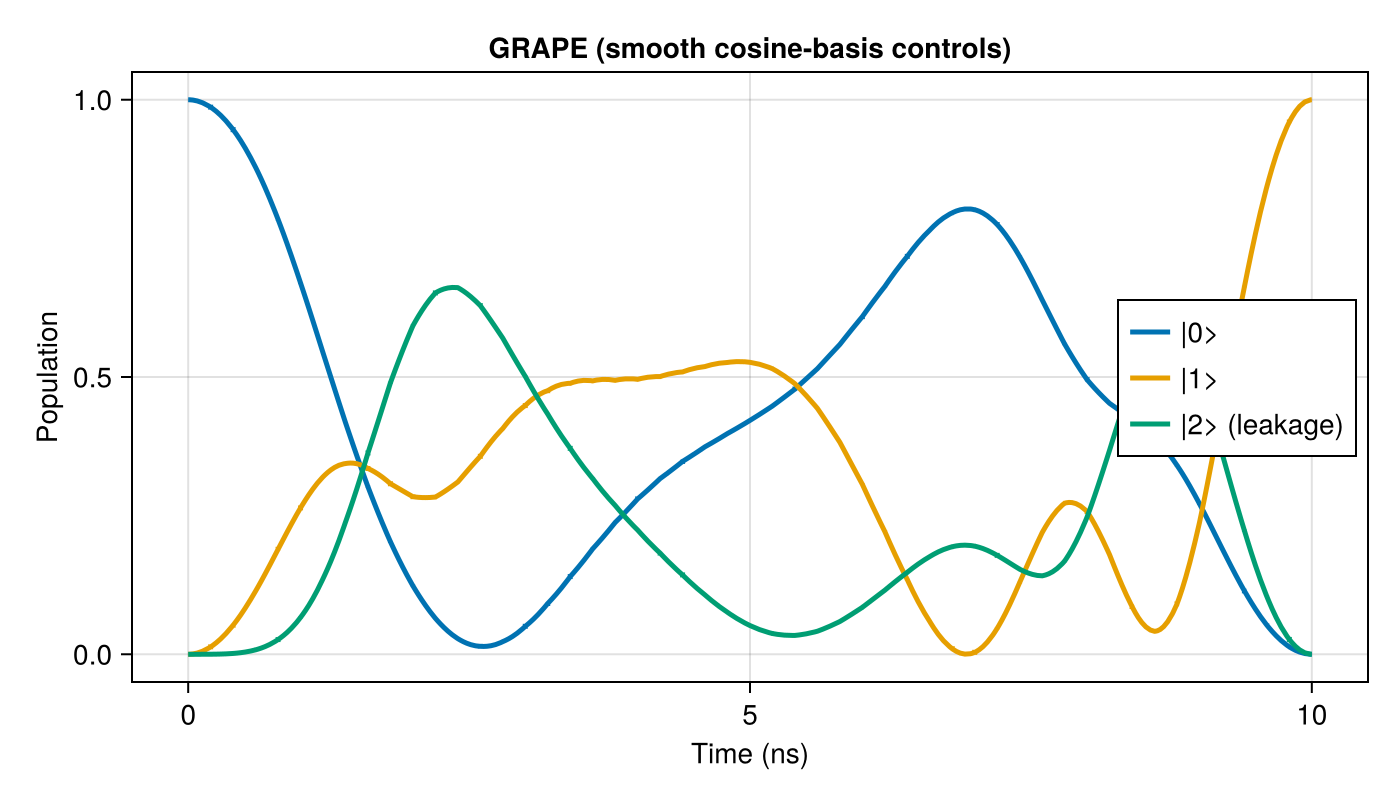

In [ ]:
best_uI_smooth = expand_control(best_smooth_coeffs[1:n_modes], g_basis)
best_uQ_smooth = expand_control(best_smooth_coeffs[n_modes+1:2n_modes], g_basis)
t_smooth, pops_smooth = population_trajectory(best_uI_smooth, best_uQ_smooth)
fig_grape_smooth = plot_populations(t_smooth, pops_smooth; title = "GRAPE (smooth cosine-basis controls)")

In [ ]:
ψ_final_raw = run_transmon(best_raw[1:N], best_raw[N+1:2N]).u[end]
fid_grape_raw = abs2(dot(ψtarget_t, ψ_final_raw))
leak_grape_raw = abs2(ψ_final_raw[3])

ψ_final_smooth = run_transmon(best_uI_smooth, best_uQ_smooth).u[end]
# Explicitly normalize state vector to clear numerical noise
ψ_final_smooth ./= norm(ψ_final_smooth)

fid_grape_smooth = min(1.0, abs2(dot(ψtarget_t, ψ_final_smooth)))


println("GRAPE (raw):    fidelity = ", fid_grape_raw, ", leakage pop = ", leak_grape_raw)
println("GRAPE (smooth): fidelity = ", fid_grape_smooth, ", leakage pop = ", leak_grape_smooth)

GRAPE (raw):    fidelity = 0.316320211591225, leakage pop = 0.011603375709895471
GRAPE (smooth): fidelity = 0.9999999985197359, leakage pop = 9.457257156733176e-8


### Pulse shapes: raw vs. smooth (your original comparison plot, extended to I/Q)

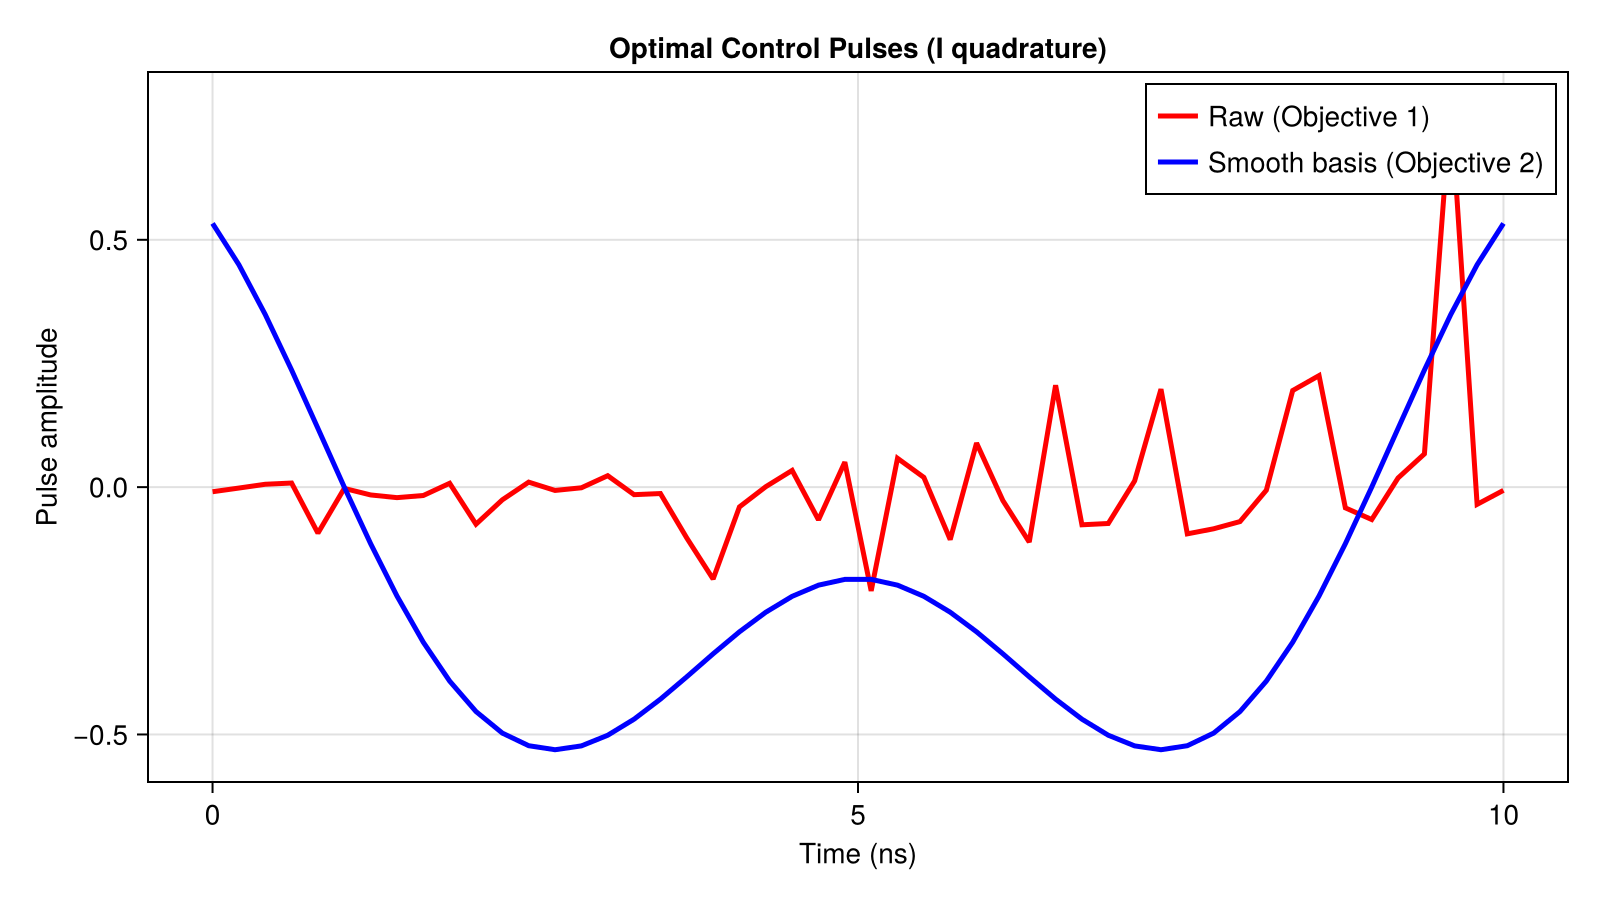

In [31]:
time_axis = times
fig_pulses = Figure(size = (800, 450))
ax = Axis(fig_pulses[1, 1], xlabel = "Time (ns)", ylabel = "Pulse amplitude",
          title = "Optimal Control Pulses (I quadrature)")
lines!(ax, time_axis, best_raw[1:N], label = "Raw (Objective 1)", color = :red, linewidth = 2.5)
lines!(ax, time_axis, best_uI_smooth, label = "Smooth basis (Objective 2)", color = :blue, linewidth = 2.5)
axislegend(ax)
fig_pulses